# YOLO Fine-tuning on VisDrone2019-DET
Author: Juan Esteban Agudelo Ortiz

Email: juan.es.agor@gmail.com

---

This notebook fine-tunes YOLO11n on the VisDrone2019-DET training set
and compares the results against the zero-shot baseline established in
the previous notebook of this series.

### What changes from the baseline notebook?
- The model is trained on VisDrone-train before evaluation
- Data augmentation is applied to expand the training distribution
- Results are compared side-by-side against the zero-shot baseline

### Dataset
- **VisDrone2019-DET**: 6,471 training images, 548 validation images
- **10 classes**: pedestrian, people, bicycle, car, van, truck, tricycle,
  awning-tricycle, bus, motor

### Limitations
1. YOLO11n is the smallest variant — larger models will yield higher mAP.
2. Small objects (<32×32 px) remain challenging even after fine-tuning.
3. Results depend on the number of epochs and hardware used.

## 0. Install dependencies

In [13]:
# Run only if not already installed
!pip install ultralytics opencv-python matplotlib numpy

## 1. Imports and configuration

Same shared directory structure as the baseline notebook. Weights and
datasets are downloaded only once and reused across all notebooks in
this series.

In [ ]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import cv2
import torch
from ultralytics import YOLO
from ultralytics.utils import SETTINGS

# Datos de Ciencia color palette
PALETTE = {
    "bg":     "#0D1117",
    "orange": "#E85D24",
    "amber":  "#F5A623",
    "yellow": "#FCDE5A",
    "white":  "#FFFFFF",
    "gray":   "#334155",
}

# Detect environment
IN_KAGGLE = os.path.exists("/kaggle/working")
print(IN_KAGGLE)

if IN_KAGGLE:
    MODELS_DIR   = Path("/kaggle/working/models")
    DATASETS_DIR = Path("/kaggle/working/datasets")
    out_dir      = Path("/kaggle/working/outputs")
else:
    MODELS_DIR   = Path("../models")
    DATASETS_DIR = Path("../data")
    out_dir      = Path("outputs")

MODELS_DIR.mkdir(exist_ok=True)
DATASETS_DIR.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)

SETTINGS.update({"datasets_dir": str(DATASETS_DIR.resolve())})

print(f"Environment : {'Kaggle' if IN_KAGGLE else 'Local'}")
print(f"Models dir  : {MODELS_DIR.resolve()}")
print(f"Datasets dir: {DATASETS_DIR.resolve()}")
print("Configuration ready ✓")

True
Environment : Kaggle
Models dir  : /kaggle/working/models
Datasets dir: /kaggle/working/datasets
Configuration ready ✓


Additional to the `MODEL_NAME`, `DATA_CONFIG` and `IMGSZ` configuration variables, we are going to define the `EPOCHS` and `BATCH` variables related to the training of the model. This variables set how many passes (epochs) on all the dataset is the model going to do on the training and which amount of images (batch size) is the model going to take until reaching the whole dataset per epoch.

In [15]:
MODEL_NAME  = str(MODELS_DIR / "yolo11n.pt")
DATA_CONFIG = "VisDrone.yaml"
IMGSZ       = 640
EPOCHS      = 100
BATCH       = 64


Let's again define explicitly the Visdrone classes and the colors of the bounding boxes.

In [17]:
VISDRONE_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]

CLASS_COLORS_BGR = [
    (36,  93, 232), (35, 165, 245), (36, 232, 166), (36, 165,  36),
    (245, 166, 35), (232,  93,  36), (166,  35, 245), (245,  35, 166),
    (36,  36, 232), (232, 232,  36),
]

%% [markdown]
## 2. Transfer learning and fine-tuning

### Transfer learning

Transfer learning reuses a model trained on a large source dataset
$\mathcal{D}_s$ as a starting point for a target dataset $\mathcal{D}_t$:

$$\theta^*_t = \arg\min_{\theta} \mathcal{L}(\mathcal{D}_t;\, \theta_0)
\quad \text{where } \theta_0 = \arg\min_{\theta} \mathcal{L}(\mathcal{D}_s;\, \theta)$$

The key assumption is that low-level features learned on $\mathcal{D}_s$
(edges, textures, gradients) transfer to $\mathcal{D}_t$, even when the
domains differ significantly.

### Fine-tuning with differentiated learning rate

Rather than training all layers at the same rate, Ultralytics applies a
differentiated learning rate strategy:

$$\Delta\theta_{backbone} = -\alpha_{low} \nabla_{\theta_{backbone}} \mathcal{L}$$
$$\Delta\theta_{head} = -\alpha_{high} \nabla_{\theta_{head}} \mathcal{L}$$

where $\alpha_{low} \ll \alpha_{high}$. The backbone already has useful
general features — it needs small updates to adapt without losing them.
The head has never seen VisDrone and needs larger updates to reach a
useful region of parameter space.

### Catastrophic forgetting and feature adaptation

If $\alpha_{backbone}$ is too high, the model destroys the general
features it learned during pretraining — a phenomenon called
**catastrophic forgetting**. The differentiated learning rate prevents
this while still allowing **feature adaptation**: the gradual adjustment
of high-level backbone features to the aerial domain.

### Data augmentation

Augmentation is applied primarily to expand the training distribution.
VisDrone covers a limited set of cities, altitudes, and lighting conditions —
far from the full deployment distribution of a real aerial surveillance system.
A secondary benefit is regularization: by never showing the model the exact
same image twice, augmentation also reduces overfitting.

The table below documents all Ultralytics augmentation parameters, their
defaults, and the decision taken for this fine-tuning run. Only `scale` is
modified from the default — all other parameters are left as-is, with the
justification documented explicitly.

| Parameter | Default | Our value | Justification |
|---|---|---|---|
| `hsv_h` | 0.015 | 0.015 | Natural hue variation across lighting conditions |
| `hsv_s` | 0.7 | 0.7 | Saturation variation covers overcast vs. sunny conditions |
| `hsv_v` | 0.4 | 0.4 | Brightness variation simulates different times of day |
| `degrees` | 0.0 | 0.0 | Strong rotations distort small objects below recognizability |
| `translate` | 0.1 | 0.1 | Mild translation helps with object positioning variability |
| `scale` | 0.5 | **0.7** | Wider range simulates more altitude variation in drone flight |
| `shear` | 0.0 | 0.0 | Not physically meaningful for nadir aerial imagery |
| `perspective` | 0.0 | 0.0 | Perspective is already fixed by the aerial viewpoint |
| `flipud` | 0.0 | 0.0 | Vertical flip violates gravitational orientation — buildings and vehicles have a defined top |
| `fliplr` | 0.5 | 0.5 | Valid — drones fly in any horizontal direction |
| `bgr` | 0.0 | 0.0 | Channel swap not relevant for RGB drone imagery |
| `mosaic` | 1.0 | 1.0 | Combines 4 images — increases small object diversity effectively |
| `mixup` | 0.0 | 0.0 | Blending two images makes small objects even harder to detect |
| `copy_paste` | 0.0 | 0.0 | Not used — label quality required for reliable copy-paste |
| `auto_augment` | randaugment | randaugment | Automatic policy provides additional variability at no tuning cost |
| `erasing` | 0.4 | 0.4 | Random erasure forces the model to use multiple object features |
| `crop_fraction` | 1.0 | 1.0 | Full image used — cropping would discard already-small objects |
| `close_mosaic` | 10 | 10 | Disables mosaic in last 10 epochs for cleaner small-object predictions |

Only `scale` is explicitly passed to `model.train()`. All other parameters
use Ultralytics defaults, which are already well-suited for this dataset.

Ultralytics also applies a set of Albumentations transforms automatically
when the library is installed. These are applied on top of the parameters
above and are controlled by the `auto_augment` parameter (default:
`randaugment`):

| Transform | Probability | Effect |
|---|---|---|
| `Blur` | 0.01 | Random blur with kernel size 3-7 |
| `MedianBlur` | 0.01 | Median blur — more robust to salt-and-pepper noise |
| `ToGray` | 0.01 | Converts image to grayscale — forces color-invariant features |
| `CLAHE` | 0.01 | Contrast Limited Adaptive Histogram Equalization — improves local contrast |

These are applied with low probability (0.01) so they affect roughly 1 in
100 images per epoch. For VisDrone this is beneficial — CLAHE in particular
helps with images taken in low-contrast conditions such as overcast days or
high-altitude shots where objects blend into the background.

## 3. Fine-tuning

We load the pretrained YOLO11n weights and fine-tune on VisDrone-train.`model.train()` handles dataset download, augmentation, and the differentiated learning rate strategy automatically. Only `scale` is modified from the default augmentation parameters (See the augmentation table above for the full justification).

In [18]:
model = YOLO(MODEL_NAME)

train_results = model.train(
    data=DATA_CONFIG,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    scale=0.7,
    project=str(out_dir),
    name="finetune_visdrone",
    exist_ok=True,
    verbose=False,
    device="0,1",  # use both T4 GPUs
)

print("Training complete ✓")
best_weights = out_dir / "finetune_visdrone" / "weights" / "best.pt"
print(f"Best weights saved to: {best_weights}")
print(f"Exists: {best_weights.exists()}")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/models/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_visd

## 4. Load fine-tuned model

After training, Ultralytics saves the best checkpoint based on validation
mAP. We load that checkpoint for evaluation and comparison against the
baseline.

In [19]:
best_weights = out_dir / "finetune_visdrone" / "weights" / "best.pt"
model_ft = YOLO(str(best_weights))
print(f"Fine-tuned model loaded: {best_weights}")

Fine-tuned model loaded: /kaggle/working/outputs/finetune_visdrone/weights/best.pt


## 5. Evaluation — baseline vs fine-tuned

We evaluate both models on the same validation set under the same
thresholds to ensure a fair comparison.

In [20]:
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

In [21]:
model_base = YOLO(MODEL_NAME)
results_base = model_base.val(
    data=DATA_CONFIG,
    imgsz=IMGSZ,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    verbose=False,
    plots=False,
)

results_ft = model_ft.val(
    data=DATA_CONFIG,
    imgsz=IMGSZ,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    verbose=False,
    plots=False,
)

print(f"{'Metric':<15} {'Baseline':>10} {'Fine-tuned':>12} {'Delta':>8}")
print("-" * 48)
metrics = [
    ("mAP@50",    results_base.box.map50, results_ft.box.map50),
    ("mAP@50-95", results_base.box.map,   results_ft.box.map),
    ("Precision",  results_base.box.mp,    results_ft.box.mp),
    ("Recall",     results_base.box.mr,    results_ft.box.mr),
]
for name, base, ft in metrics:
    delta = ft - base
    print(f"{name:<15} {base:>10.4f} {ft:>12.4f} {delta:>+8.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2810.2±677.9 MB/s, size: 145.3 KB)
val: Scanning /kaggle/working/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 229.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 10.7it/s 3.3s0.2s
                   all        548      38759     0.0717     0.0127    0.00585     0.0031
Speed: 0.5ms preprocess, 2.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2652.2±550.3 MB/s, size: 142.1 KB)
val: Scanning /kaggle/working/datasets/VisDrone

## 6. Per-class metrics comparison

In [22]:
def get_per_class(results):
    per_class = {}
    for idx, ap50 in zip(results.box.ap_class_index, results.box.ap50):
        cls_name = VISDRONE_CLASSES[idx] if idx < len(VISDRONE_CLASSES) else f"cls_{idx}"
        per_class[cls_name] = float(ap50)
    return per_class

per_class_base = get_per_class(results_base)
per_class_ft   = get_per_class(results_ft)
all_classes    = sorted(set(per_class_base) | set(per_class_ft))

print(f"{'Class':<20} {'Baseline':>10} {'Fine-tuned':>12} {'Delta':>8}")
print("-" * 53)
for cls in sorted(all_classes, key=lambda c: -per_class_ft.get(c, 0)):
    base  = per_class_base.get(cls, 0.0)
    ft    = per_class_ft.get(cls, 0.0)
    delta = ft - base
    print(f"{cls:<20} {base:>10.4f} {ft:>12.4f} {delta:>+8.4f}")

Class                  Baseline   Fine-tuned    Delta
-----------------------------------------------------
car                      0.0001       0.6913  +0.6913
bus                      0.0000       0.3756  +0.3756
pedestrian               0.0541       0.2724  +0.2183
van                      0.0000       0.2619  +0.2619
motor                    0.0000       0.2443  +0.2443
truck                    0.0028       0.2139  +0.2111
people                   0.0000       0.1685  +0.1685
tricycle                 0.0000       0.1320  +0.1320
bicycle                  0.0000       0.0538  +0.0538
awning-tricycle          0.0015       0.0490  +0.0475


## 7. Metrics visualization

/tmp/ipykernel_57/3427746736.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


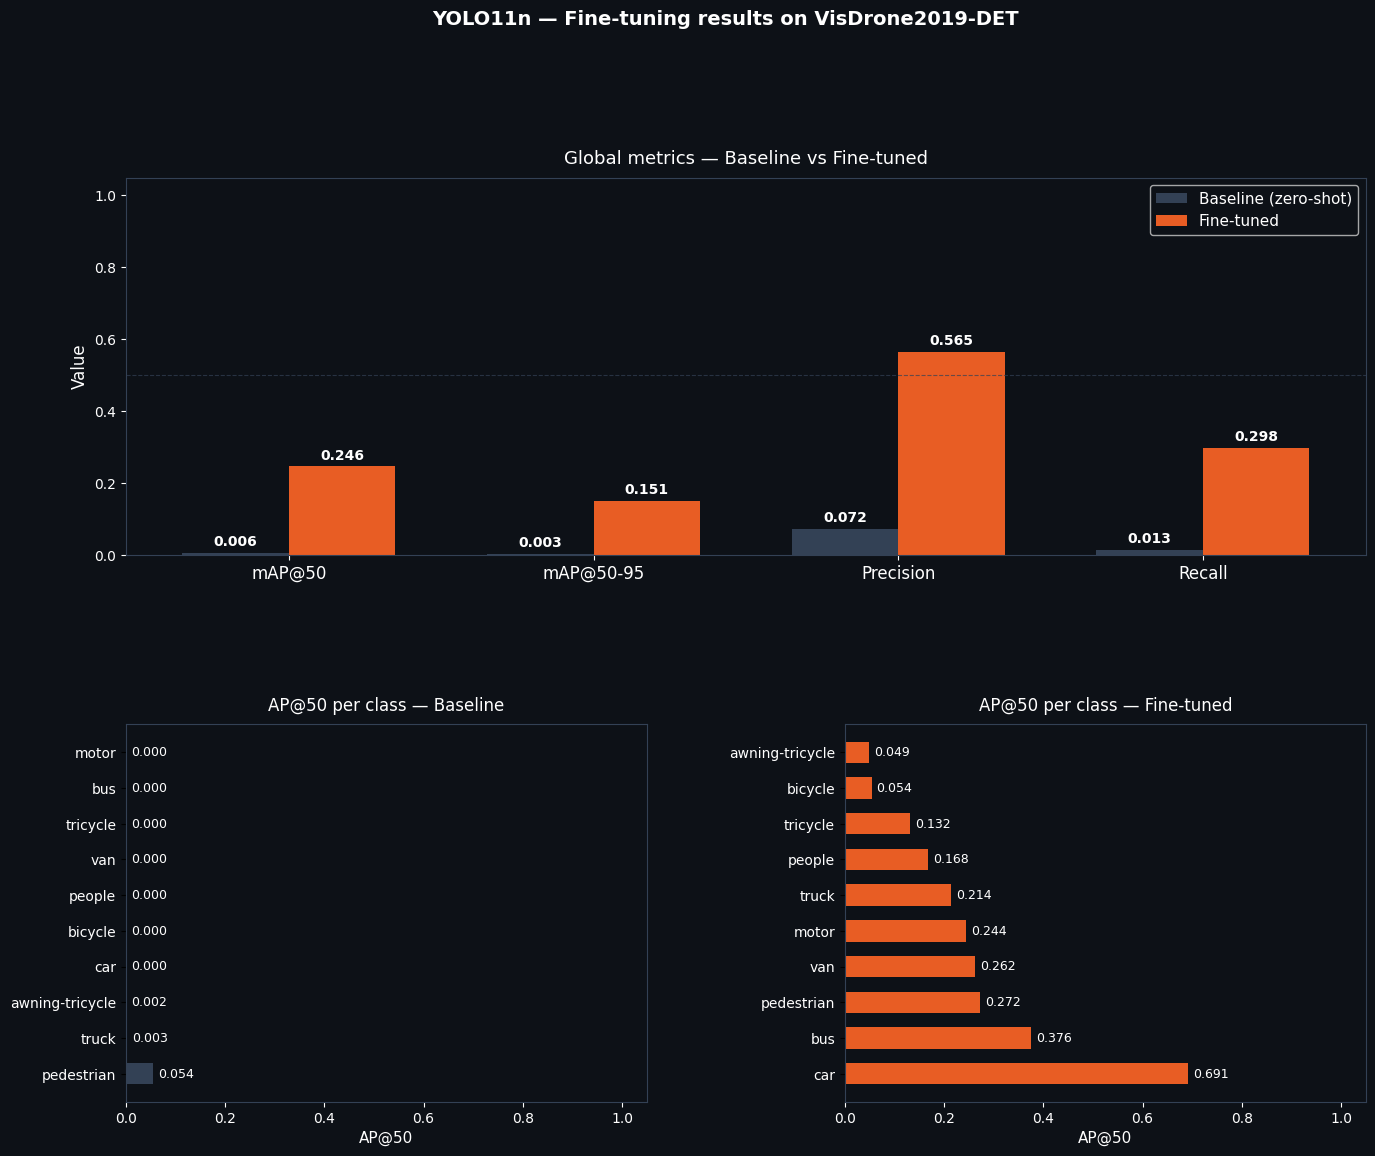

Figure saved to outputs/metrics_comparison.png


In [23]:
fig = plt.figure(figsize=(16, 12), facecolor=PALETTE["bg"])
gs  = GridSpec(2, 2, figure=fig, wspace=0.38, hspace=0.45)

# ── Global metrics comparison ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(PALETTE["bg"])

metric_names = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
base_vals    = [results_base.box.map50, results_base.box.map,
                results_base.box.mp,    results_base.box.mr]
ft_vals      = [results_ft.box.map50,   results_ft.box.map,
                results_ft.box.mp,      results_ft.box.mr]

x     = np.arange(len(metric_names))
width = 0.35

bars_base = ax1.bar(x - width/2, base_vals, width,
                    color=PALETTE["gray"],   label="Baseline (zero-shot)",
                    edgecolor="none")
bars_ft   = ax1.bar(x + width/2, ft_vals,   width,
                    color=PALETTE["orange"], label="Fine-tuned",
                    edgecolor="none")

ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, color=PALETTE["white"], fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.tick_params(colors=PALETTE["white"])
ax1.spines[:].set_color(PALETTE["gray"])
ax1.set_ylabel("Value", color=PALETTE["white"], fontsize=12)
ax1.set_title("Global metrics — Baseline vs Fine-tuned",
              color=PALETTE["white"], fontsize=13, pad=10)
ax1.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["white"], fontsize=11)
ax1.axhline(0.5, color=PALETTE["gray"], linestyle="--",
            linewidth=0.8, alpha=0.7)

for bar, val in zip(bars_base, base_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", color=PALETTE["white"],
             fontsize=10, fontweight="bold")
for bar, val in zip(bars_ft, ft_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", color=PALETTE["white"],
             fontsize=10, fontweight="bold")

# ── Per-class AP baseline ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(PALETTE["bg"])
sorted_pairs_base = sorted(per_class_base.items(), key=lambda x: -x[1])
cls_names_base, ap_vals_base = zip(*sorted_pairs_base)
y_pos = np.arange(len(cls_names_base))
ax2.barh(y_pos, ap_vals_base, color=PALETTE["gray"],
         edgecolor="none", height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(cls_names_base, color=PALETTE["white"], fontsize=10)
ax2.set_xlim(0, 1.05)
ax2.tick_params(axis="x", colors=PALETTE["white"])
ax2.spines[:].set_color(PALETTE["gray"])
ax2.set_xlabel("AP@50", color=PALETTE["white"], fontsize=11)
ax2.set_title("AP@50 per class — Baseline",
              color=PALETTE["white"], fontsize=12, pad=10)
for i, val in enumerate(ap_vals_base):
    ax2.text(val + 0.01, i, f"{val:.3f}", va="center",
             color=PALETTE["white"], fontsize=9)

# ── Per-class AP fine-tuned ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(PALETTE["bg"])
sorted_pairs_ft = sorted(per_class_ft.items(), key=lambda x: -x[1])
cls_names_ft, ap_vals_ft = zip(*sorted_pairs_ft)
y_pos_ft = np.arange(len(cls_names_ft))
ax3.barh(y_pos_ft, ap_vals_ft, color=PALETTE["orange"],
         edgecolor="none", height=0.6)
ax3.set_yticks(y_pos_ft)
ax3.set_yticklabels(cls_names_ft, color=PALETTE["white"], fontsize=10)
ax3.set_xlim(0, 1.05)
ax3.tick_params(axis="x", colors=PALETTE["white"])
ax3.spines[:].set_color(PALETTE["gray"])
ax3.set_xlabel("AP@50", color=PALETTE["white"], fontsize=11)
ax3.set_title("AP@50 per class — Fine-tuned",
              color=PALETTE["white"], fontsize=12, pad=10)
for i, val in enumerate(ap_vals_ft):
    ax3.text(val + 0.01, i, f"{val:.3f}", va="center",
             color=PALETTE["white"], fontsize=9)

fig.suptitle("YOLO11n — Fine-tuning results on VisDrone2019-DET",
             color=PALETTE["white"], fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(out_dir / "metrics_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Figure saved to outputs/metrics_comparison.png")

## 8. Visual comparison — baseline vs fine-tuned

We run both models on the same images and display predictions side by side.
This makes the improvement visible before looking at any numbers.

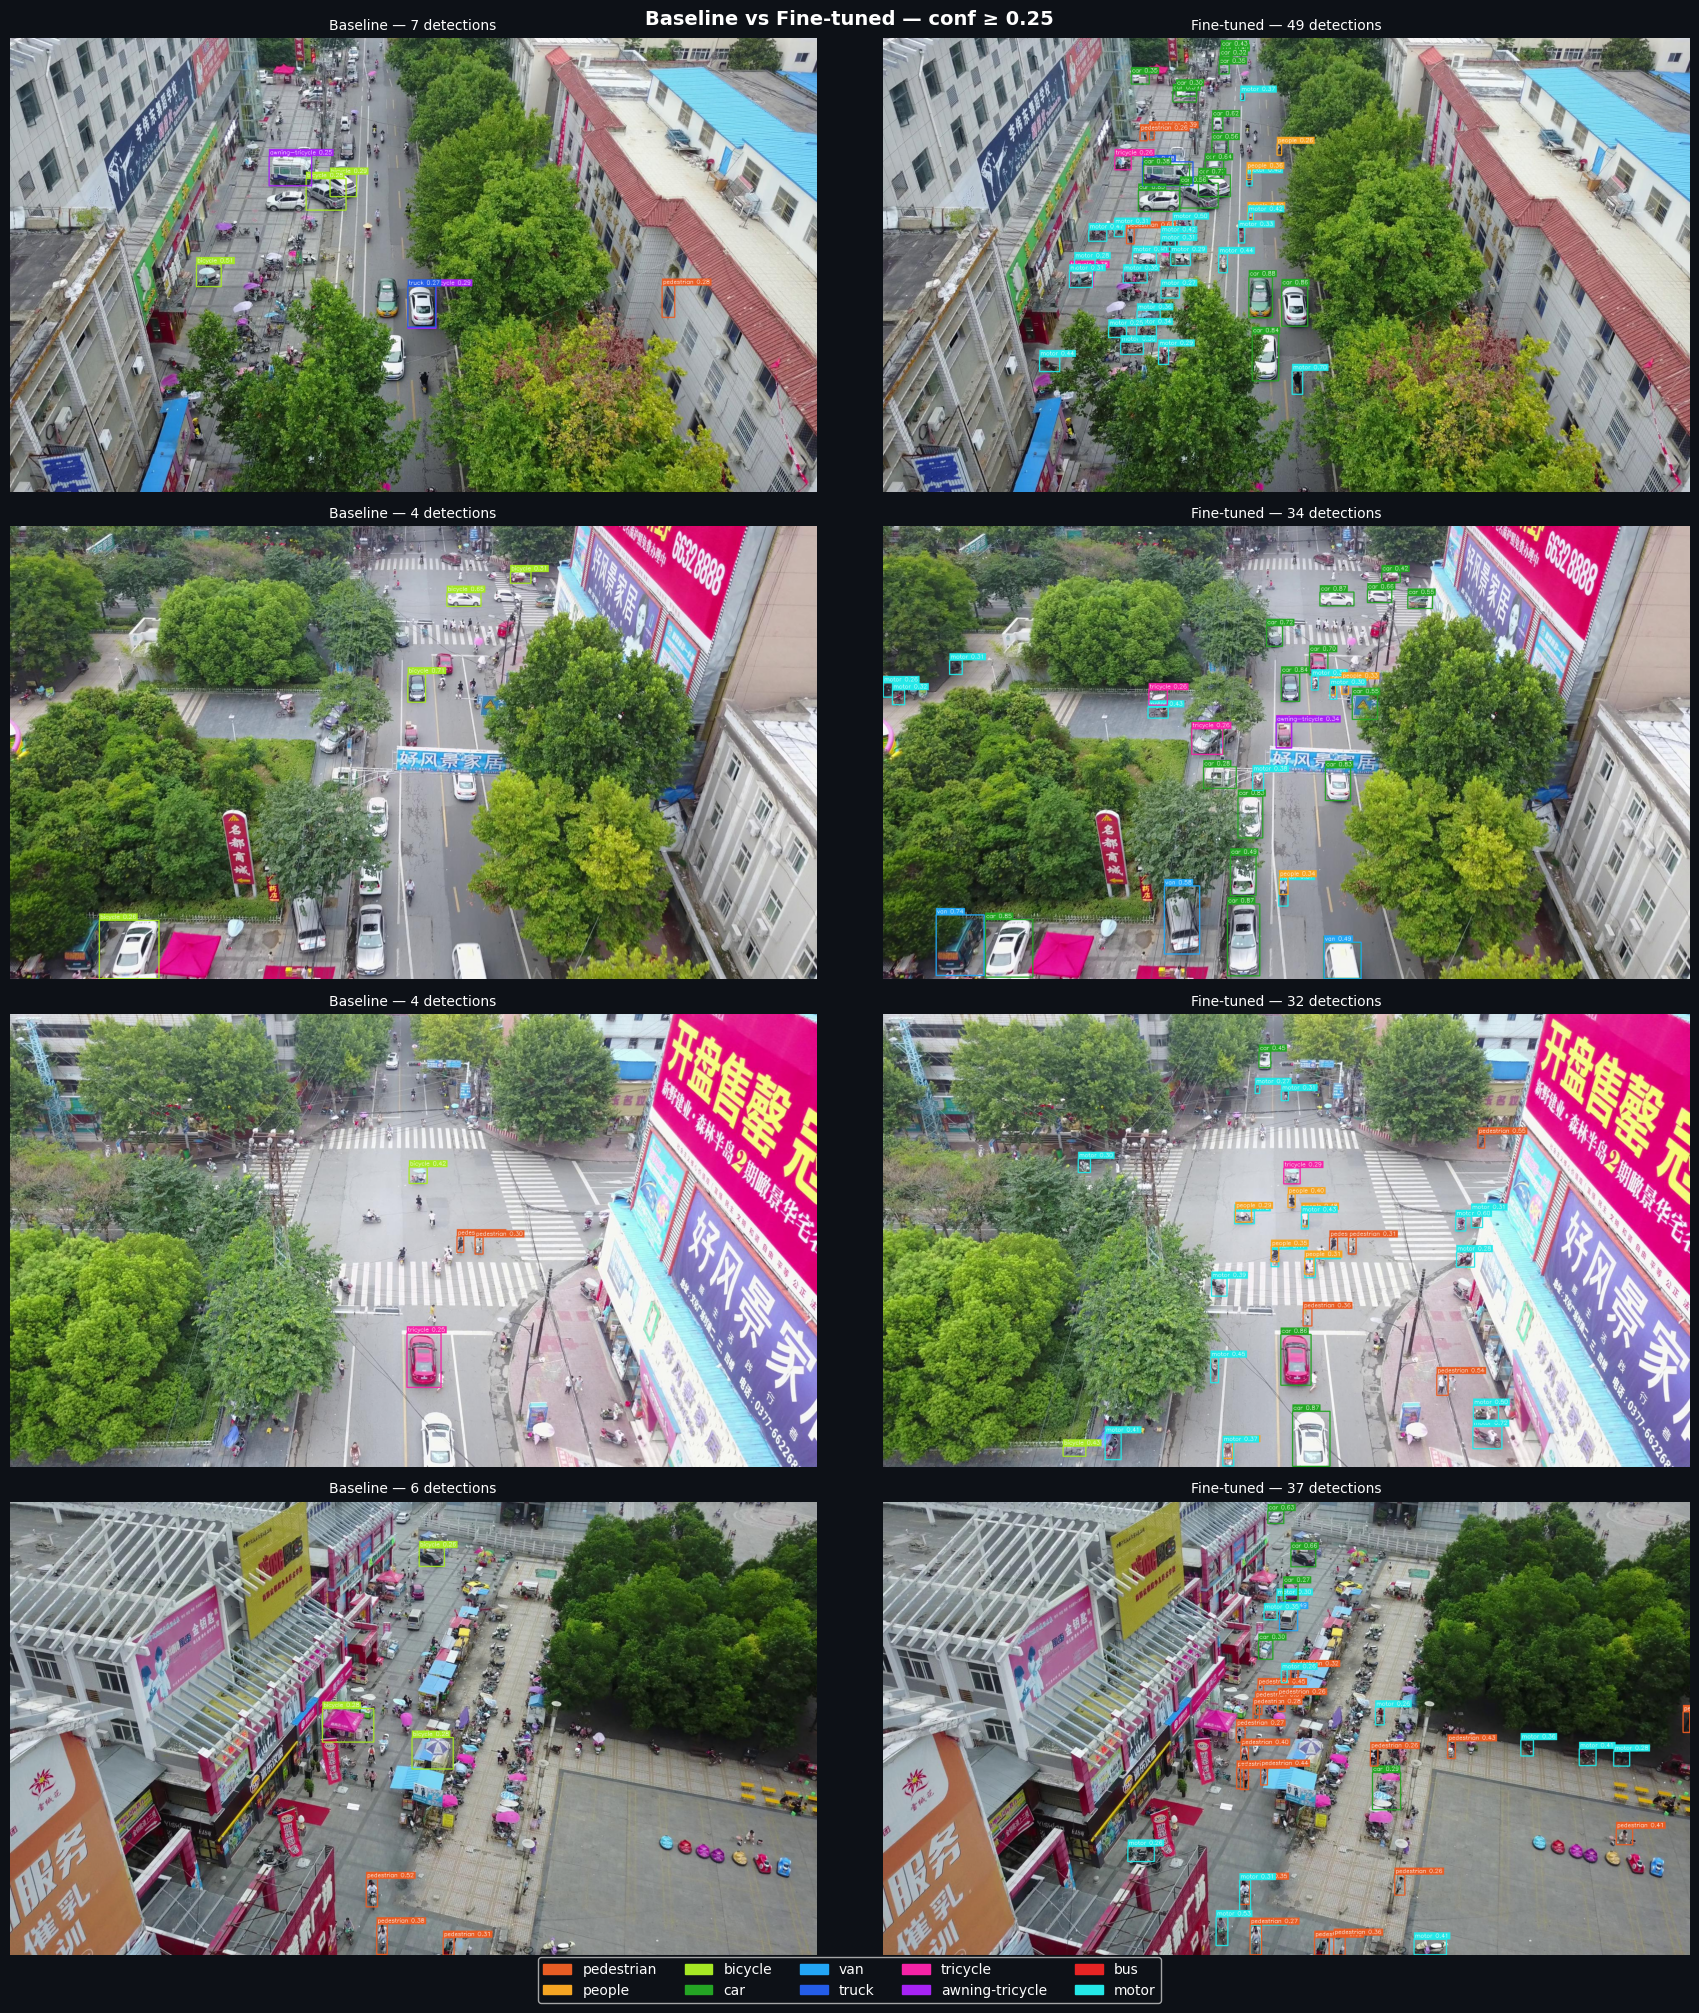

Grid saved to outputs/predictions_comparison.png


In [24]:
N_VIZ   = 4
val_dir = DATASETS_DIR / "VisDrone" / "images" / "val"
img_paths = sorted(val_dir.glob("*.jpg"))[:N_VIZ]

results_base_viz = model_base.predict(
    source=[str(p) for p in img_paths],
    conf=CONF_THRESH, iou=IOU_THRESH, imgsz=IMGSZ, verbose=False,
)
results_ft_viz = model_ft.predict(
    source=[str(p) for p in img_paths],
    conf=CONF_THRESH, iou=IOU_THRESH, imgsz=IMGSZ, verbose=False,
)

def draw_boxes(img_path, res, ax, title):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if res.boxes is not None and len(res.boxes):
        for box in res.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            color  = CLASS_COLORS_BGR[cls_id % len(CLASS_COLORS_BGR)][::-1]
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            label = f"{VISDRONE_CLASSES[cls_id] if cls_id < len(VISDRONE_CLASSES) else cls_id} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            cv2.rectangle(img_rgb, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
            cv2.putText(img_rgb, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
    n_det = len(res.boxes) if res.boxes is not None else 0
    ax.imshow(img_rgb)
    ax.set_title(f"{title} — {n_det} detections",
                 color=PALETTE["white"], fontsize=10)
    ax.axis("off")
    ax.set_facecolor(PALETTE["bg"])

fig, axes = plt.subplots(N_VIZ, 2, figsize=(18, N_VIZ * 5),
                          facecolor=PALETTE["bg"])
for i, (img_path, res_b, res_f) in enumerate(
    zip(img_paths, results_base_viz, results_ft_viz)
):
    draw_boxes(img_path, res_b, axes[i][0], "Baseline")
    draw_boxes(img_path, res_f, axes[i][1], "Fine-tuned")

patches = [
    mpatches.Patch(color=[c/255 for c in CLASS_COLORS_BGR[j][::-1]],
                   label=VISDRONE_CLASSES[j])
    for j in range(len(VISDRONE_CLASSES))
]
fig.legend(handles=patches, loc="lower center", ncol=5,
           facecolor=PALETTE["bg"], labelcolor=PALETTE["white"],
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Baseline vs Fine-tuned — conf ≥ {CONF_THRESH}",
             color=PALETTE["white"], fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(out_dir / "predictions_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Grid saved to outputs/predictions_comparison.png")

## 9. Summary

### What fine-tuning changed

Fine-tuning on VisDrone-train exposes the model to the aerial perspective,
small object sizes, and the specific class distribution of the dataset.
The differentiated learning rate strategy preserves the general features
learned on COCO while adapting the head and high-level backbone features
to the new domain.

### What augmentation contributed

Augmentation expanded the training distribution beyond the 14 cities
covered by VisDrone. The increased `scale` range (0.7) exposed the model
to a wider range of simulated altitudes, and disabling `flipud` ensured
that no physically impossible orientations were introduced. Ultralytics
also applied Albumentations transforms automatically (Blur, MedianBlur,
ToGray, CLAHE) with probability 0.01 each, providing additional
low-frequency variability.

### Remaining limitations

1. YOLO11n is the smallest variant — larger models will yield higher mAP.
2. Small objects (<32×32 px) remain challenging even after fine-tuning.
3. The model is still limited to the 10 VisDrone classes.

### What comes next

The next notebook applies the same fine-tuning approach to a scientific
dataset — solar imagery from the SDO — to demonstrate that the same
technique transfers across domains far beyond aerial surveillance.